In [1]:
import pandas as pd

df = pd.read_csv("data.csv")

print(df.head())
print(df.info())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [2]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df = df.drop('id', axis=1)
df = df.drop('Unnamed: 32', axis=1)
# Handle missing values
df = df.dropna()

# Convert categorical → numeric (if any)
df = pd.get_dummies(df, drop_first=True)
target_column = 'diagnosis'

X = df.drop(target_column, axis=1)
y = df[target_column]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [5]:
y_pred_nb = model_nb.predict(X_test)
y_prob_nb = model_nb.predict_proba(X_test)[:,1]

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

Accuracy: 0.9736842105263158
Confusion Matrix:
 [[71  0]
 [ 3 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



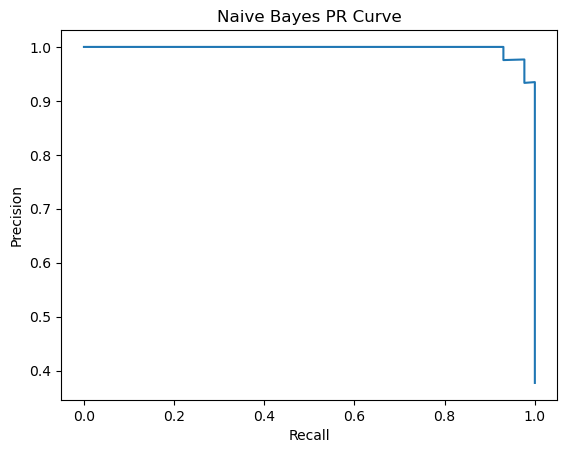

In [7]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_nb, recall_nb, _ = precision_recall_curve(y_test, y_prob_nb)

plt.plot(recall_nb, precision_nb)
plt.title("Naive Bayes PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [8]:
# Experiment 2

In [9]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:,1]

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.9473684210526315
Confusion Matrix:
 [[68  3]
 [ 3 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



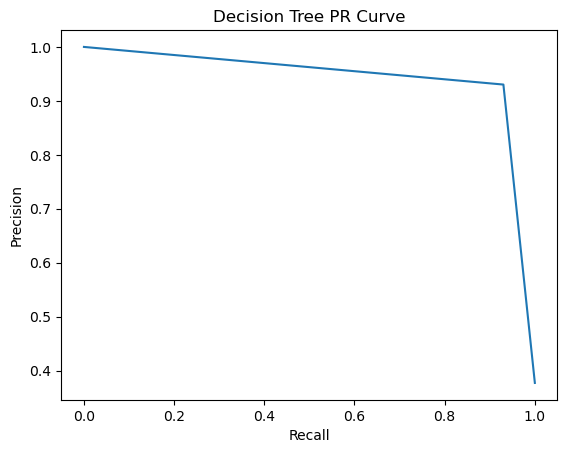

In [12]:
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt)

plt.plot(recall_dt, precision_dt)
plt.title("Decision Tree PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

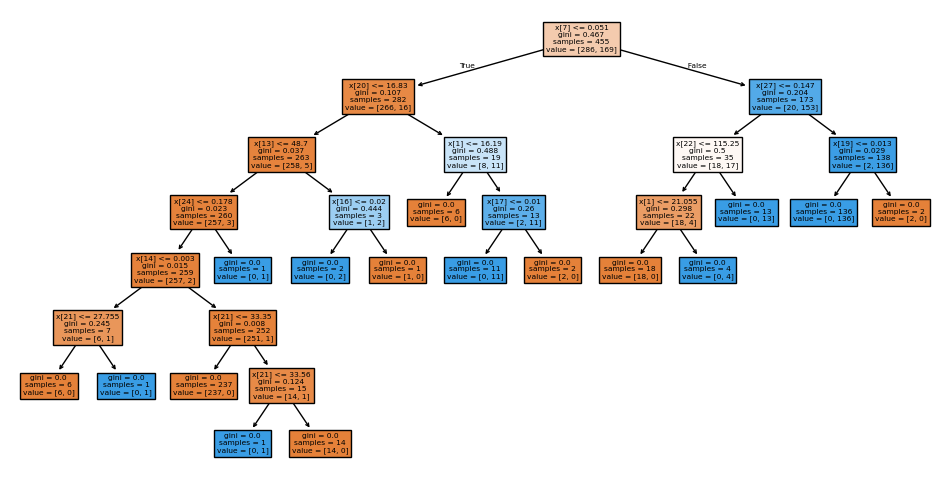

In [13]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,6))
plot_tree(model_dt, filled=True)
plt.show()

In [14]:
# Experiment 3

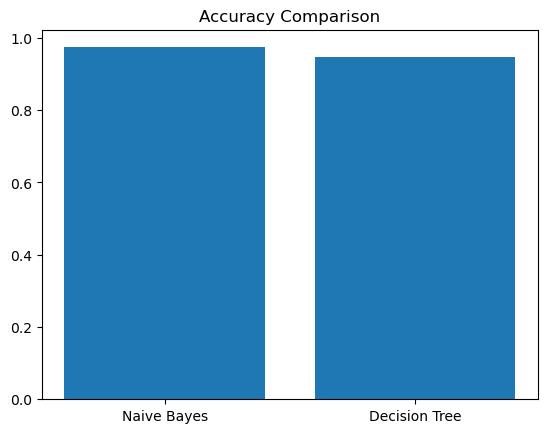

In [15]:
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_dt = accuracy_score(y_test, y_pred_dt)

plt.bar(['Naive Bayes', 'Decision Tree'], [acc_nb, acc_dt])
plt.title("Accuracy Comparison")
plt.show()

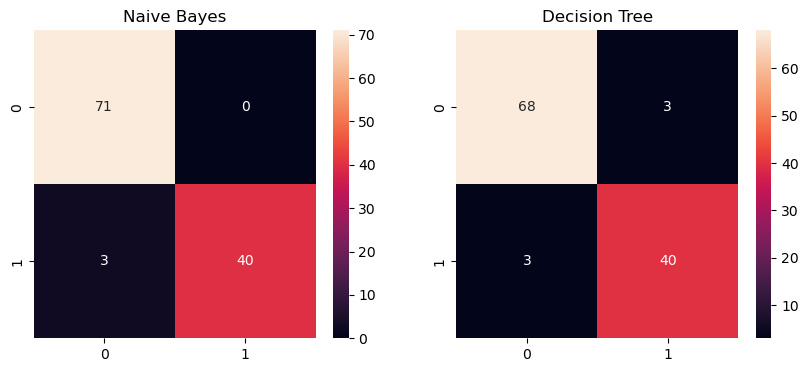

In [16]:
import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d')
plt.title("Naive Bayes")

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.title("Decision Tree")

plt.show()